In [1]:
# !pip install ncmcm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import os
from IPython import display

## Load Data (excluding behavioural neurons)

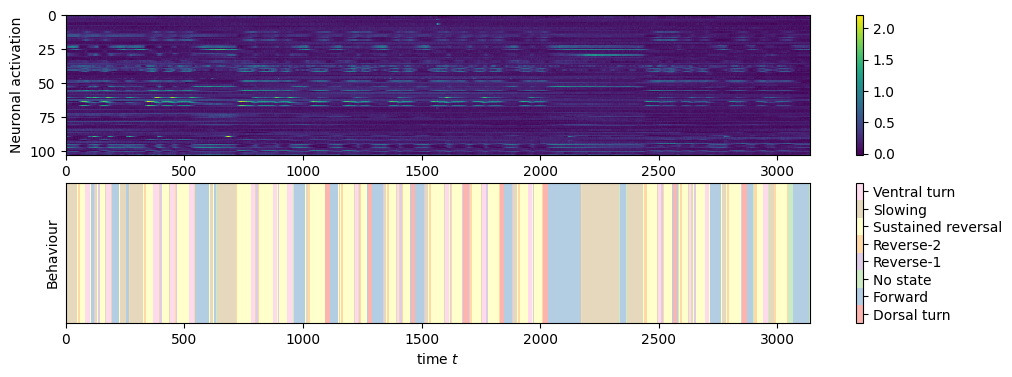

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [2]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour
behavior = list(data.behaviour_names.values())
os.chdir('..')

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Comparison Plots

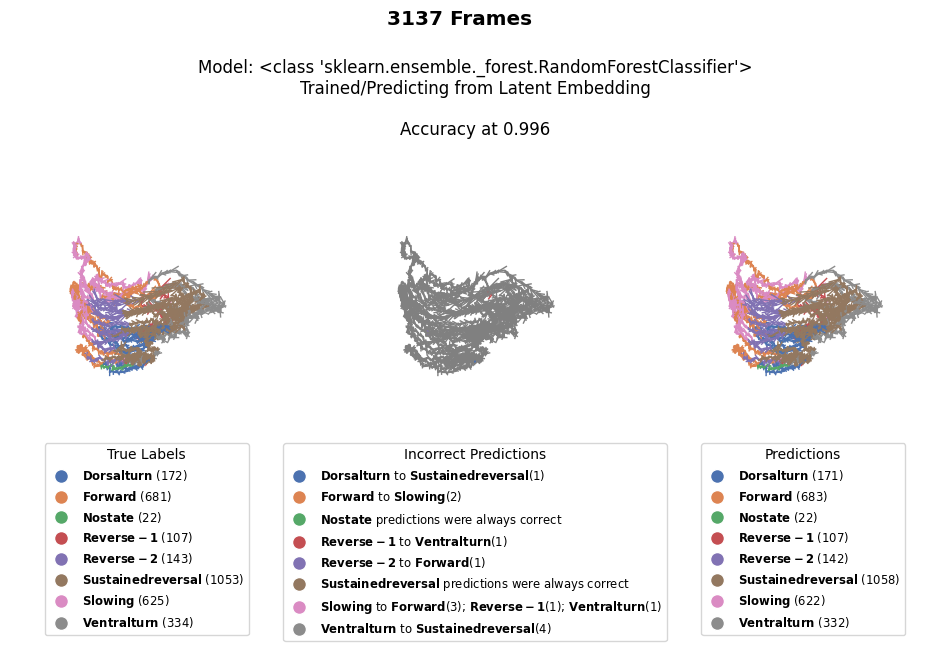

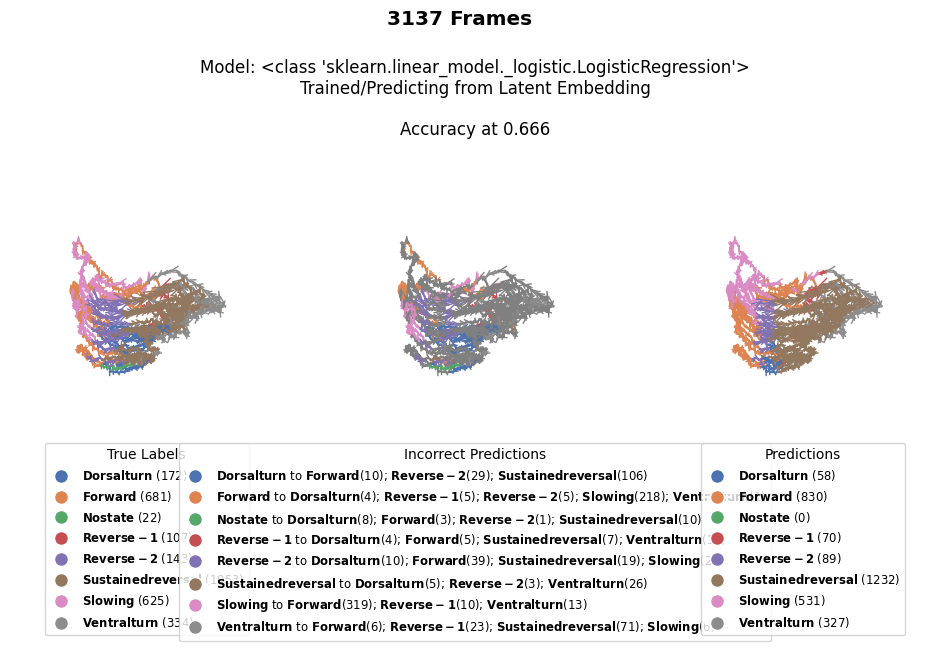

True

In [4]:
# To use the comparison plot we first need an embedding
pca = PCA(n_components=3)
x_embedded = pca.fit_transform(x)
lsv = LatentSpaceVisualiser(x_embedded, b, b_names=behavior, legend=True)
# Now we use this embedding to plot our time-series and the predictions of a model of our choice
RFC = RandomForestClassifier(n_estimators=20)
LG = LogisticRegression(max_iter=1000)
lsv.comparison_model(RFC, fig_size=(12,8), filename='figures/comparison_rfc')
lsv.comparison_model(LG, fig_size=(12,8), filename='figures/comparison_lg')
# We can see the differences when predicting labels from the embedding, what abot from the original data? Lets see

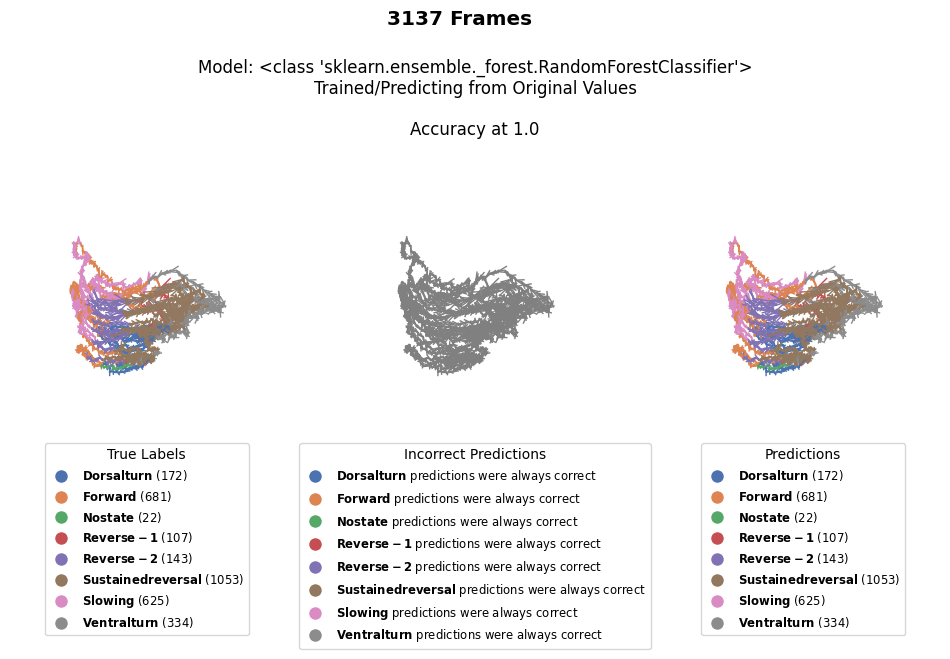

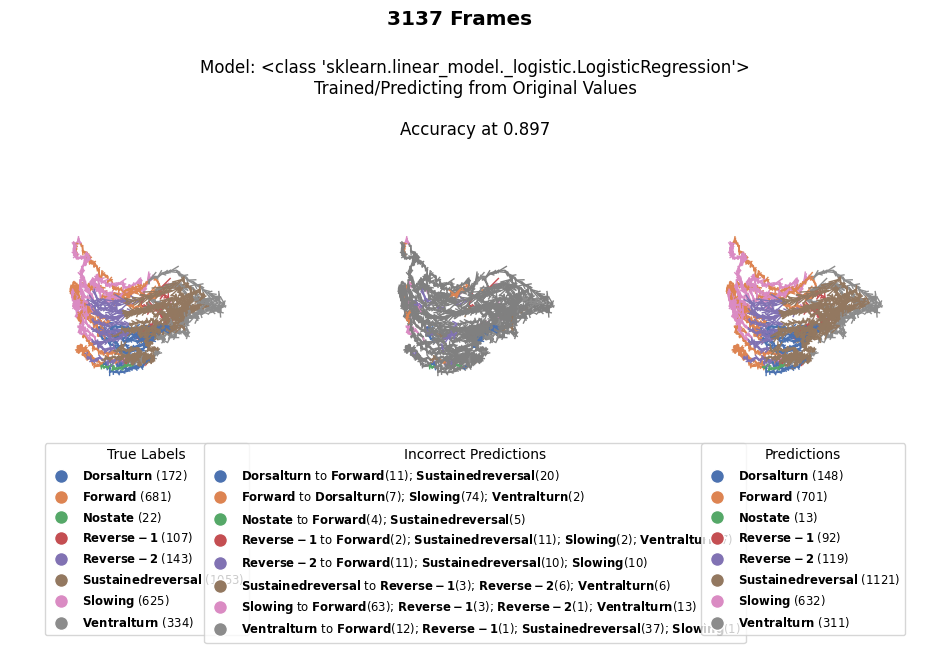

True

In [5]:
# Now we use the original data to predict
lsv.comparison_model(RFC, fig_size=(12,8), original_data=x, filename='figures/comparison_rfc')
lsv.comparison_model(LG, fig_size=(12,8), original_data=x, filename='figures/comparison_lg')
# When using the original neuronal data to predict the behavior the results are more similar for the logistic regression and the random forest.

## Movie Maker (GIF)

In [8]:
# We use Bundle-Net for visualisation
x_, b_ = prep_data(x, b, win=15)
# Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names))
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=1000
)
y0_ = model.tau(x_[:, 0]).numpy()

Loss [Markov, Behaviour, Total]: [0.0079 0.0166 0.0245]: 100%|██████████| 1000/1000 [00:44<00:00, 22.59it/s]


True

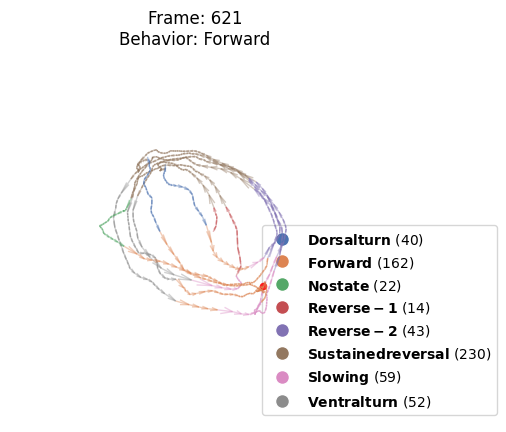

In [9]:
# This can take quite some time to render with bigger datasets
# That is why we cut our dataset for display purposes:
x_embedded_2 = y0_[2500:, :]
b_2 = b_[2500:]
lsv_2 = LatentSpaceVisualiser(x_embedded_2, 
                              b_2, 
                              b_names=behavior, 
                              legend=True)
lsv_2.make_movie(fps=30, 
                 filename='figures/worm_0_movie.gif',
                 show_fig=False)

<img src="figures/worm_0_movie.gif">

True

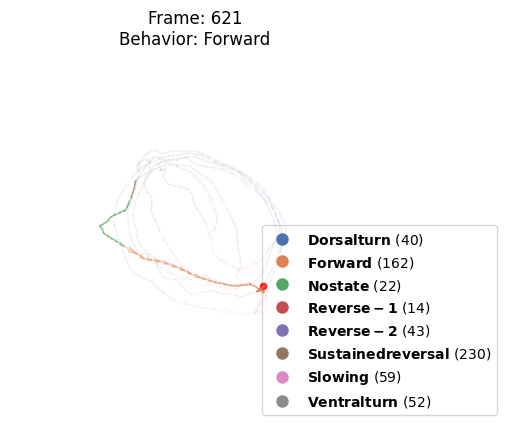

In [10]:
# The make_movie method has parameters that allow the user to fade the animation or add a background manifold.
lsv_2.make_movie(fps=50, 
                 filename='figures/worm_0_fading_movie.gif',
                 show_fig=False,
                 initial_alpha=0.05,
                 fade=100)
os.chdir('figures')

<img src="figures/worm_0_fading_movie.gif">
